In [6]:
# ─────────────────────────────────────────────
# 1 : Librairies
# ─────────────────────────────────────────────

# Classic
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import polars as pl

# Probabilities
from scipy.optimize import curve_fit
from nucleo.simulation.probabilities import proba_gamma

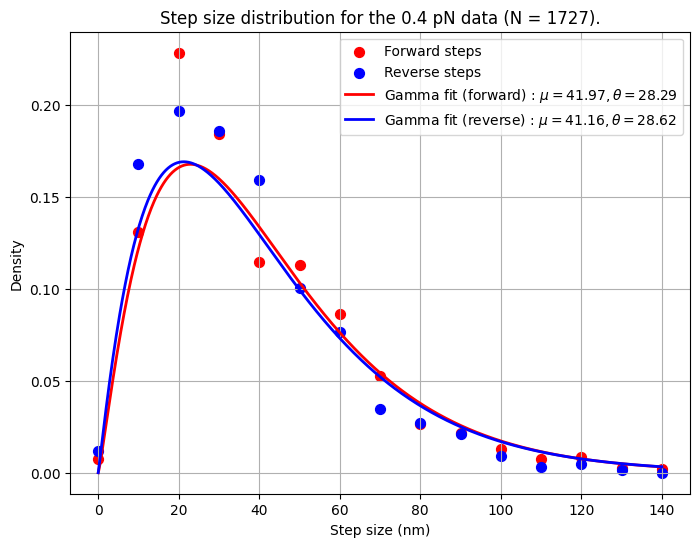

In [7]:
# ─────────────────────────────────────────────
# 2 : Datas + Fits + Conversions
# ─────────────────────────────────────────────

# Data
step_array = np.linspace(0, 140, 15)
frwd_array = np.array([8, 139, 243, 196, 122, 120, 92, 56, 28, 23, 14, 8, 9, 3, 2], dtype=float)
rvrs_array = np.array([8, 112, 131, 124, 106, 67, 51, 23, 18, 14, 6, 2, 3, 1, 0], dtype=float)
frwd_array /= np.sum(frwd_array)
rvrs_array /= np.sum(rvrs_array)

# Fitting
def gamma_fit(x, mu, theta):
    return proba_gamma(mu, theta, x)

popt_frwd, pcov_frwd = curve_fit(
    gamma_fit,
    step_array[1:],
    frwd_array[1:],
    p0=(20.0, 20.0),
    bounds=([1e-3, 1e-3], [np.inf, np.inf]),
)

popt_rvrs, pcov_rvrs = curve_fit(
    gamma_fit,
    step_array[1:],
    rvrs_array[1:],
    p0=(20.0, 20.0),
    bounds=([1e-3, 1e-3], [np.inf, np.inf]),
)

# 
x_fit = np.linspace(step_array.min(), step_array.max(), 1000)
y_fit_frwd = proba_gamma(popt_frwd[0], popt_frwd[1], x_fit) * 1000 / 15
y_fit_rvrs = proba_gamma(popt_rvrs[0], popt_rvrs[1], x_fit) * 1000 / 15


# Plot
plt.figure(figsize=(8,6))
plt.scatter(step_array, frwd_array, c="r", marker="o", s=50, label=rf"Forward steps")
plt.scatter(step_array, rvrs_array, c="b", marker="o", s=50, label=rf"Reverse steps")
plt.plot(x_fit, y_fit_frwd, "r-", lw=2, label=rf"Gamma fit (forward) : $\mu={popt_frwd[0]:.2f}, \theta={popt_frwd[1]:.2f}$")
plt.plot(x_fit, y_fit_rvrs, "b-", lw=2, label=rf"Gamma fit (reverse) : $\mu={popt_rvrs[0]:.2f}, \theta={popt_rvrs[1]:.2f}$")
plt.title("Step size distribution for the 0.4 pN data (N = 1727).")
plt.xlabel("Step size (nm)")
plt.ylabel("Density")
plt.grid(True)
plt.legend()
plt.show()

λ = 0.38519375361480623


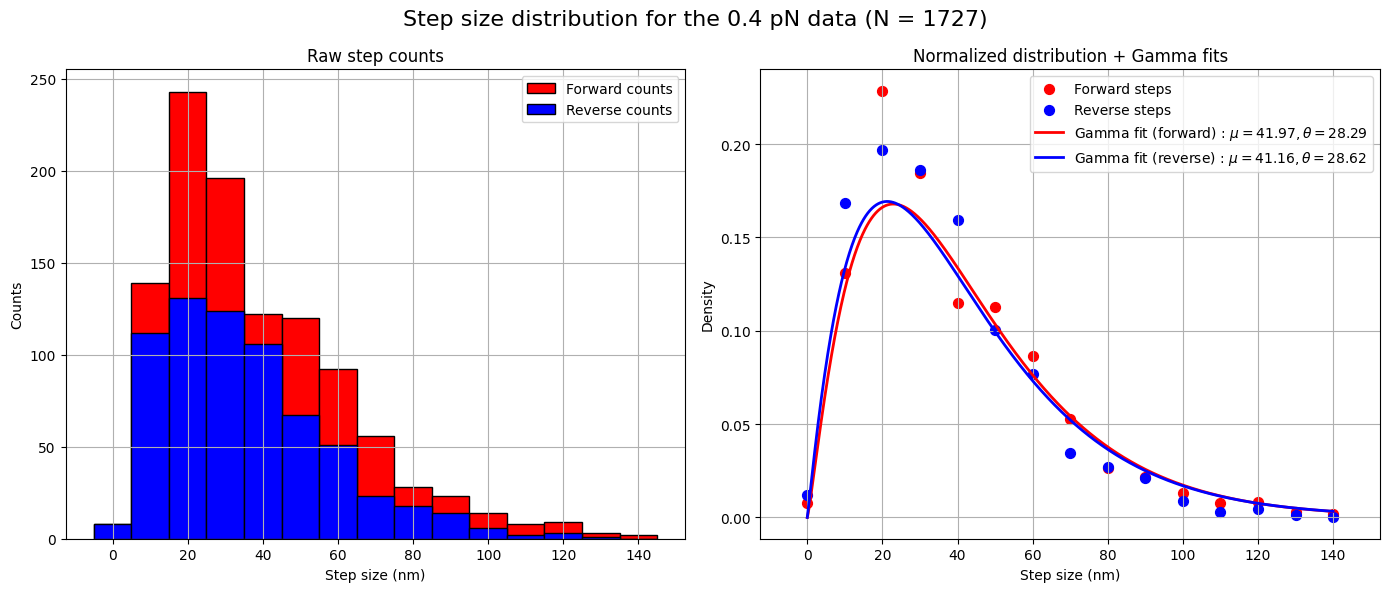

In [8]:
# ─────────────────────────────────────────────
# 2 : Datas + Fits + Conversions
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit

# Data
step_array = np.linspace(0, 140, 15)

frwd_counts = np.array([8, 139, 243, 196, 122, 120, 92, 56, 28, 23, 14, 8, 9, 3, 2], dtype=float)
rvrs_counts = np.array([8, 112, 131, 124, 106, 67, 51, 23, 18, 14, 6, 2, 3, 1, 0], dtype=float)
lmbda = np.sum(rvrs_counts) / (np.sum(frwd_counts) + np.sum(rvrs_counts))
print(f"λ = {lmbda}")

# Normalized densities
frwd_array = frwd_counts / np.sum(frwd_counts)
rvrs_array = rvrs_counts / np.sum(rvrs_counts)

# Gamma model
def gamma_fit(x, mu, theta):
    return proba_gamma(mu, theta, x)

# Fitting (exclude x = 0)
popt_frwd, pcov_frwd = curve_fit(
    gamma_fit,
    step_array[1:],
    frwd_array[1:],
    p0=(20.0, 20.0),
    bounds=([1e-3, 1e-3], [np.inf, np.inf]),
)

popt_rvrs, pcov_rvrs = curve_fit(
    gamma_fit,
    step_array[1:],
    rvrs_array[1:],
    p0=(20.0, 20.0),
    bounds=([1e-3, 1e-3], [np.inf, np.inf]),
)

# Smooth fit curves
x_fit = np.linspace(step_array.min(), step_array.max(), 1000)
y_fit_frwd = proba_gamma(popt_frwd[0], popt_frwd[1], x_fit) * 1000 / 15
y_fit_rvrs = proba_gamma(popt_rvrs[0], popt_rvrs[1], x_fit) * 1000 / 15

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────

fig, (ax_counts, ax_fit) = plt.subplots(
    1, 2, figsize=(14, 6), sharex=True
)

bin_width = step_array[1] - step_array[0]

ax_counts.bar(
    step_array,
    frwd_counts,
    width=bin_width,
    color="red",
    alpha=1.0,
    edgecolor="black",
    linewidth=1.0,
    label="Forward counts",
)

ax_counts.bar(
    step_array,
    rvrs_counts,
    width=bin_width,
    color="blue",
    alpha=1.0,
    edgecolor="black",
    linewidth=1.0,
    label="Reverse counts",
)


ax_counts.set_xlabel("Step size (nm)")
ax_counts.set_ylabel("Counts")
ax_counts.set_title("Raw step counts")
ax_counts.grid(True)
ax_counts.legend()

# Right subplot: normalized densities + Gamma fits
ax_fit.scatter(
    step_array, frwd_array,
    c="r", s=50, label="Forward steps"
)
ax_fit.scatter(
    step_array, rvrs_array,
    c="b", s=50, label="Reverse steps"
)

ax_fit.plot(
    x_fit, y_fit_frwd, "r-", lw=2,
    label=rf"Gamma fit (forward) : $\mu={popt_frwd[0]:.2f}, \theta={popt_frwd[1]:.2f}$"
)
ax_fit.plot(
    x_fit, y_fit_rvrs, "b-", lw=2,
    label=rf"Gamma fit (reverse) : $\mu={popt_rvrs[0]:.2f}, \theta={popt_rvrs[1]:.2f}$"
)

ax_fit.set_xlabel("Step size (nm)")
ax_fit.set_ylabel("Density")
ax_fit.set_title("Normalized distribution + Gamma fits")
ax_fit.grid(True)
ax_fit.legend()

# Global title
fig.suptitle(
    "Step size distribution for the 0.4 pN data (N = 1727)",
    fontsize=16
)

plt.tight_layout()
plt.show()


In [9]:
# Values in nm
mu_nm = (popt_frwd[0] + popt_rvrs[0]) / 2
theta_nm = (popt_frwd[1] + popt_rvrs[1]) / 2
print(f"mu = {mu_nm:.2f} nm ; theta = {theta_nm:.2f} nm")

# Values in bp
conv = (0.246 + 0.255 + 0.257) / 3
mu_bp, theta_bp = mu_nm / conv, theta_nm / conv
print(f"mu = {mu_bp:.2f} bp ; theta = {theta_bp:.2f} bp")

# Values rounded
mu_site, theta_site = 150, 100  
print(f"mu = {mu_site} bp ; theta = {theta_site} bp")


mu = 41.57 nm ; theta = 28.46 nm
mu = 164.52 bp ; theta = 112.63 bp
mu = 150 bp ; theta = 100 bp


λ = 0.385


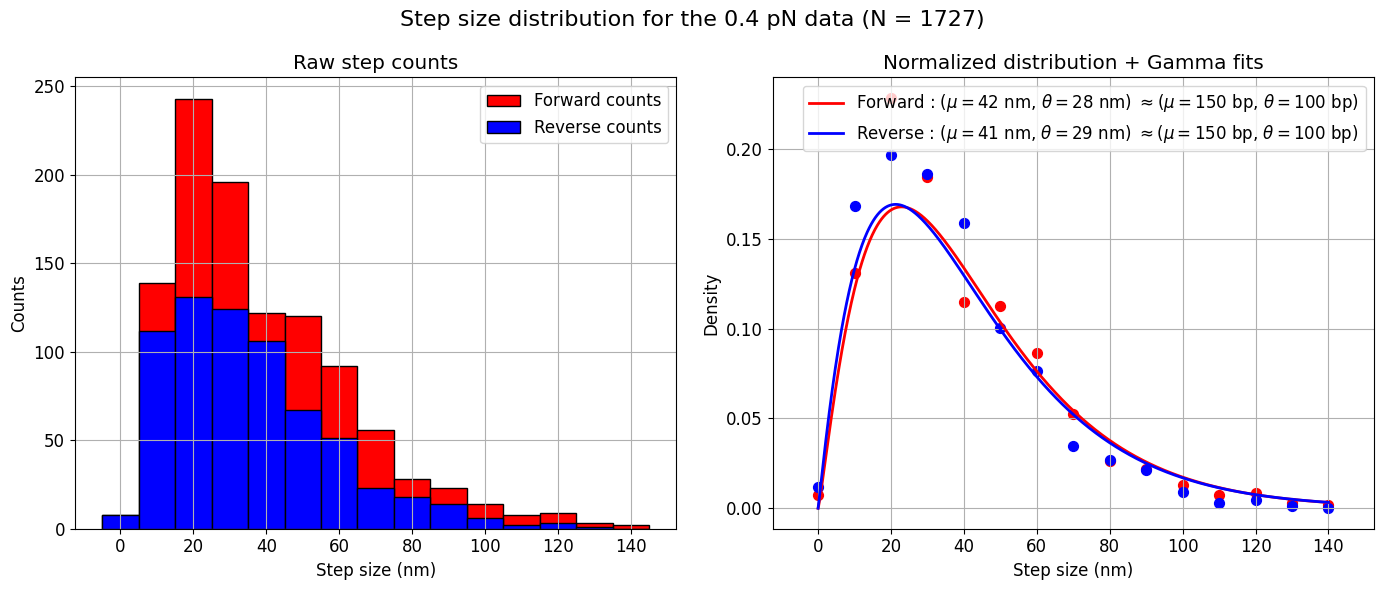


---------------- Forward fit ----------------
μ = 41.97 nm
θ = 28.29 nm
μ = 166.12 bp
θ = 111.98 bp

---------------- Reverse fit ----------------
μ = 41.16 nm
θ = 28.62 nm
μ = 162.91 bp
θ = 113.28 bp


In [29]:
# ─────────────────────────────────────────────
# 2 : Datas + Fits + Conversions
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from nucleo.simulation.probabilities import proba_gamma

# ==========================================================
# Data
# ==========================================================

step_array = np.linspace(0, 140, 15)

frwd_counts = np.array(
    [8, 139, 243, 196, 122, 120, 92, 56, 28, 23, 14, 8, 9, 3, 2],
    dtype=float,
)

rvrs_counts = np.array(
    [8, 112, 131, 124, 106, 67, 51, 23, 18, 14, 6, 2, 3, 1, 0],
    dtype=float,
)

lmbda = np.sum(rvrs_counts) / (np.sum(frwd_counts) + np.sum(rvrs_counts))
print(f"λ = {lmbda:.3f}")

# ==========================================================
# Normalized distributions
# ==========================================================

frwd_array = frwd_counts / np.sum(frwd_counts)
rvrs_array = rvrs_counts / np.sum(rvrs_counts)


def gamma_fit(x, mu, theta):
    return proba_gamma(mu, theta, x)


# ==========================================================
# Gamma fits
# ==========================================================

popt_frwd, pcov_frwd = curve_fit(
    gamma_fit,
    step_array[1:],
    frwd_array[1:],
    p0=(20, 20),
    bounds=([1e-3, 1e-3], [np.inf, np.inf]),
)

popt_rvrs, pcov_rvrs = curve_fit(
    gamma_fit,
    step_array[1:],
    rvrs_array[1:],
    p0=(20, 20),
    bounds=([1e-3, 1e-3], [np.inf, np.inf]),
)

# ==========================================================
# Smooth curves
# ==========================================================

x_fit = np.linspace(step_array.min(), step_array.max(), 1000)

y_fit_frwd = proba_gamma(*popt_frwd, x_fit) * 1000 / 15
y_fit_rvrs = proba_gamma(*popt_rvrs, x_fit) * 1000 / 15

# ==========================================================
# Plot
# ==========================================================

fig, (ax_counts, ax_fit) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharex=True,
)

bin_width = step_array[1] - step_array[0]

# ----------------------------------------------------------
# Counts
# ----------------------------------------------------------

ax_counts.bar(
    step_array,
    frwd_counts,
    width=bin_width,
    color="red",
    edgecolor="black",
    linewidth=1,
    label="Forward counts",
)

ax_counts.bar(
    step_array,
    rvrs_counts,
    width=bin_width,
    color="blue",
    edgecolor="black",
    linewidth=1,
    label="Reverse counts",
)

ax_counts.set_xlabel("Step size (nm)")
ax_counts.set_ylabel("Counts")
ax_counts.set_title("Raw step counts")
ax_counts.grid(True)
ax_counts.legend()

# ----------------------------------------------------------
# Fits
# ----------------------------------------------------------

ax_fit.scatter(
    step_array,
    frwd_array,
    c="r",
    s=50,
    # label="Forward steps",
)

ax_fit.scatter(
    step_array,
    rvrs_array,
    c="b",
    s=50,
    # label="Reverse steps",
)

ax_fit.plot(
    x_fit,
    y_fit_frwd,
    "r",
    lw=2,
    label=rf"Forward : $(\mu={popt_frwd[0]:.0f}$ nm, $\theta={popt_frwd[1]:.0f}$ nm) $\approx (\mu = 150$ bp, $\theta = 100$ bp)",
)

ax_fit.plot(
    x_fit,
    y_fit_rvrs,
    "b",
    lw=2,
    label=rf"Reverse : $(\mu={popt_rvrs[0]:.0f}$ nm, $\theta={popt_rvrs[1]:.0f}$ nm) $\approx (\mu = 150$ bp, $\theta = 100$ bp)",
)

ax_fit.set_xlabel("Step size (nm)")
ax_fit.set_ylabel("Density")
ax_fit.set_title("Normalized distribution + Gamma fits")
ax_fit.grid(True)
ax_fit.legend()

fig.suptitle(
    "Step size distribution for the 0.4 pN data (N = 1727)",
    fontsize=16,
)

plt.tight_layout()
plt.show()

# ==========================================================
# Conversions
# ==========================================================

# 1 bp = 0.2527 nm (average rise)
NM_PER_BP = np.mean([0.246, 0.255, 0.257])

# Number of bp represented by one simulation site
BP_PER_SITE = 150

print("\n---------------- Forward fit ----------------")

mu_nm, theta_nm = popt_frwd

mu_bp = mu_nm / NM_PER_BP
theta_bp = theta_nm / NM_PER_BP


print(f"μ = {mu_nm:.2f} nm")
print(f"θ = {theta_nm:.2f} nm")

print(f"μ = {mu_bp:.2f} bp")
print(f"θ = {theta_bp:.2f} bp")


print("\n---------------- Reverse fit ----------------")

mu_nm, theta_nm = popt_rvrs

mu_bp = mu_nm / NM_PER_BP
theta_bp = theta_nm / NM_PER_BP

mu_site = mu_bp / BP_PER_SITE
theta_site = theta_bp / BP_PER_SITE

print(f"μ = {mu_nm:.2f} nm")
print(f"θ = {theta_nm:.2f} nm")

print(f"μ = {mu_bp:.2f} bp")
print(f"θ = {theta_bp:.2f} bp")

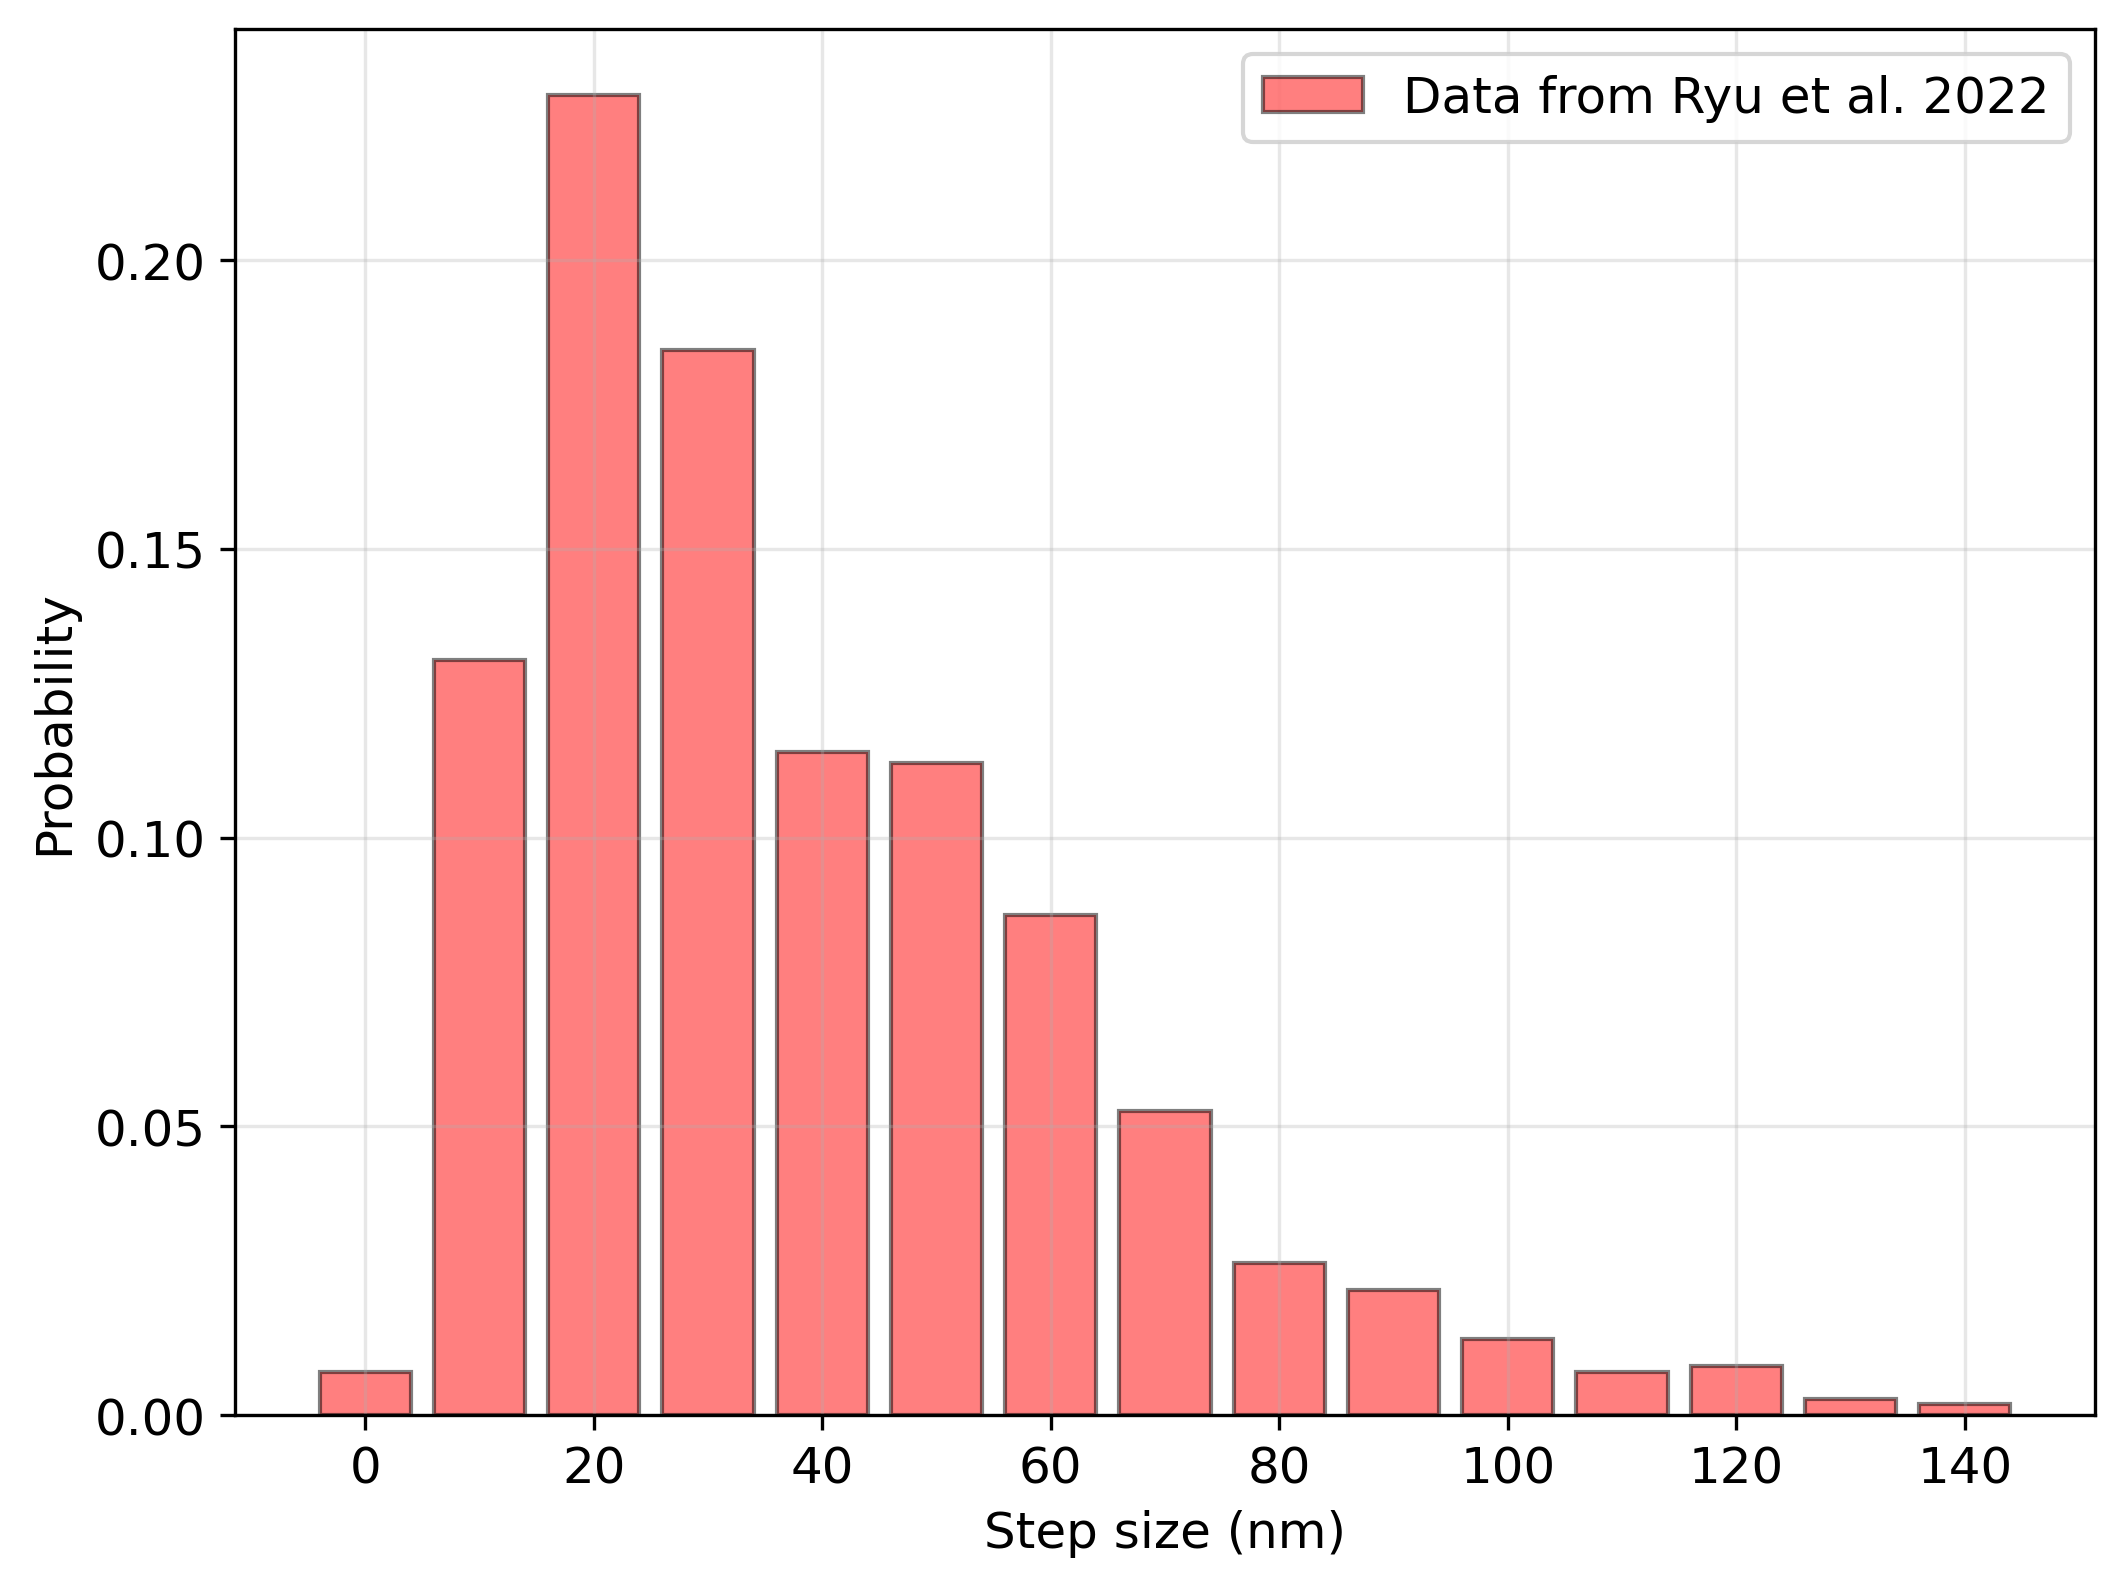

In [ ]:
# Librairies
import matplotlib.pyplot as plt
import numpy as np
from nucleo.simulation.probabilities import proba_gamma
plt.rcParams["font.size"] = 12


# Données expérimentales
step_array = np.linspace(0, 140, 15)
frwd_counts = np.array(
    [8, 139, 243, 196, 122, 120, 92, 56, 28, 23, 14, 8, 9, 3, 2],
dtype=float,
)
frwd_counts /= np.sum(frwd_counts)  # normalisation à 1

CONV = np.mean([0.246, 0.255, 0.257])


# PDF théorique
x_fine = np.arange(0, 150, 1)
nu_nm = 150 * CONV
theta_nm = 100 * CONV
p = proba_gamma(mu=nu_nm, theta=theta_nm, L=x_fine)
p /= np.sum(p)  # normalisation à 1

# -------------------------------
# Subplots côte à côte
# -------------------------------
plt.figure(figsize=(8, 6), dpi=300)

bin_width = 10

plt.bar(
    step_array, frwd_counts,
    width=bin_width-2,
    edgecolor="black",
    color="red",
    alpha=0.5,
    label="Data from Ryu et al. 2022",
    lw=1
)
#
plt.xlabel("Step size (nm)")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.legend(fontsize=12)
plt.show()

mu    = 37.72 ± 1.34 nm
theta = 24.42 ± 1.53 nm


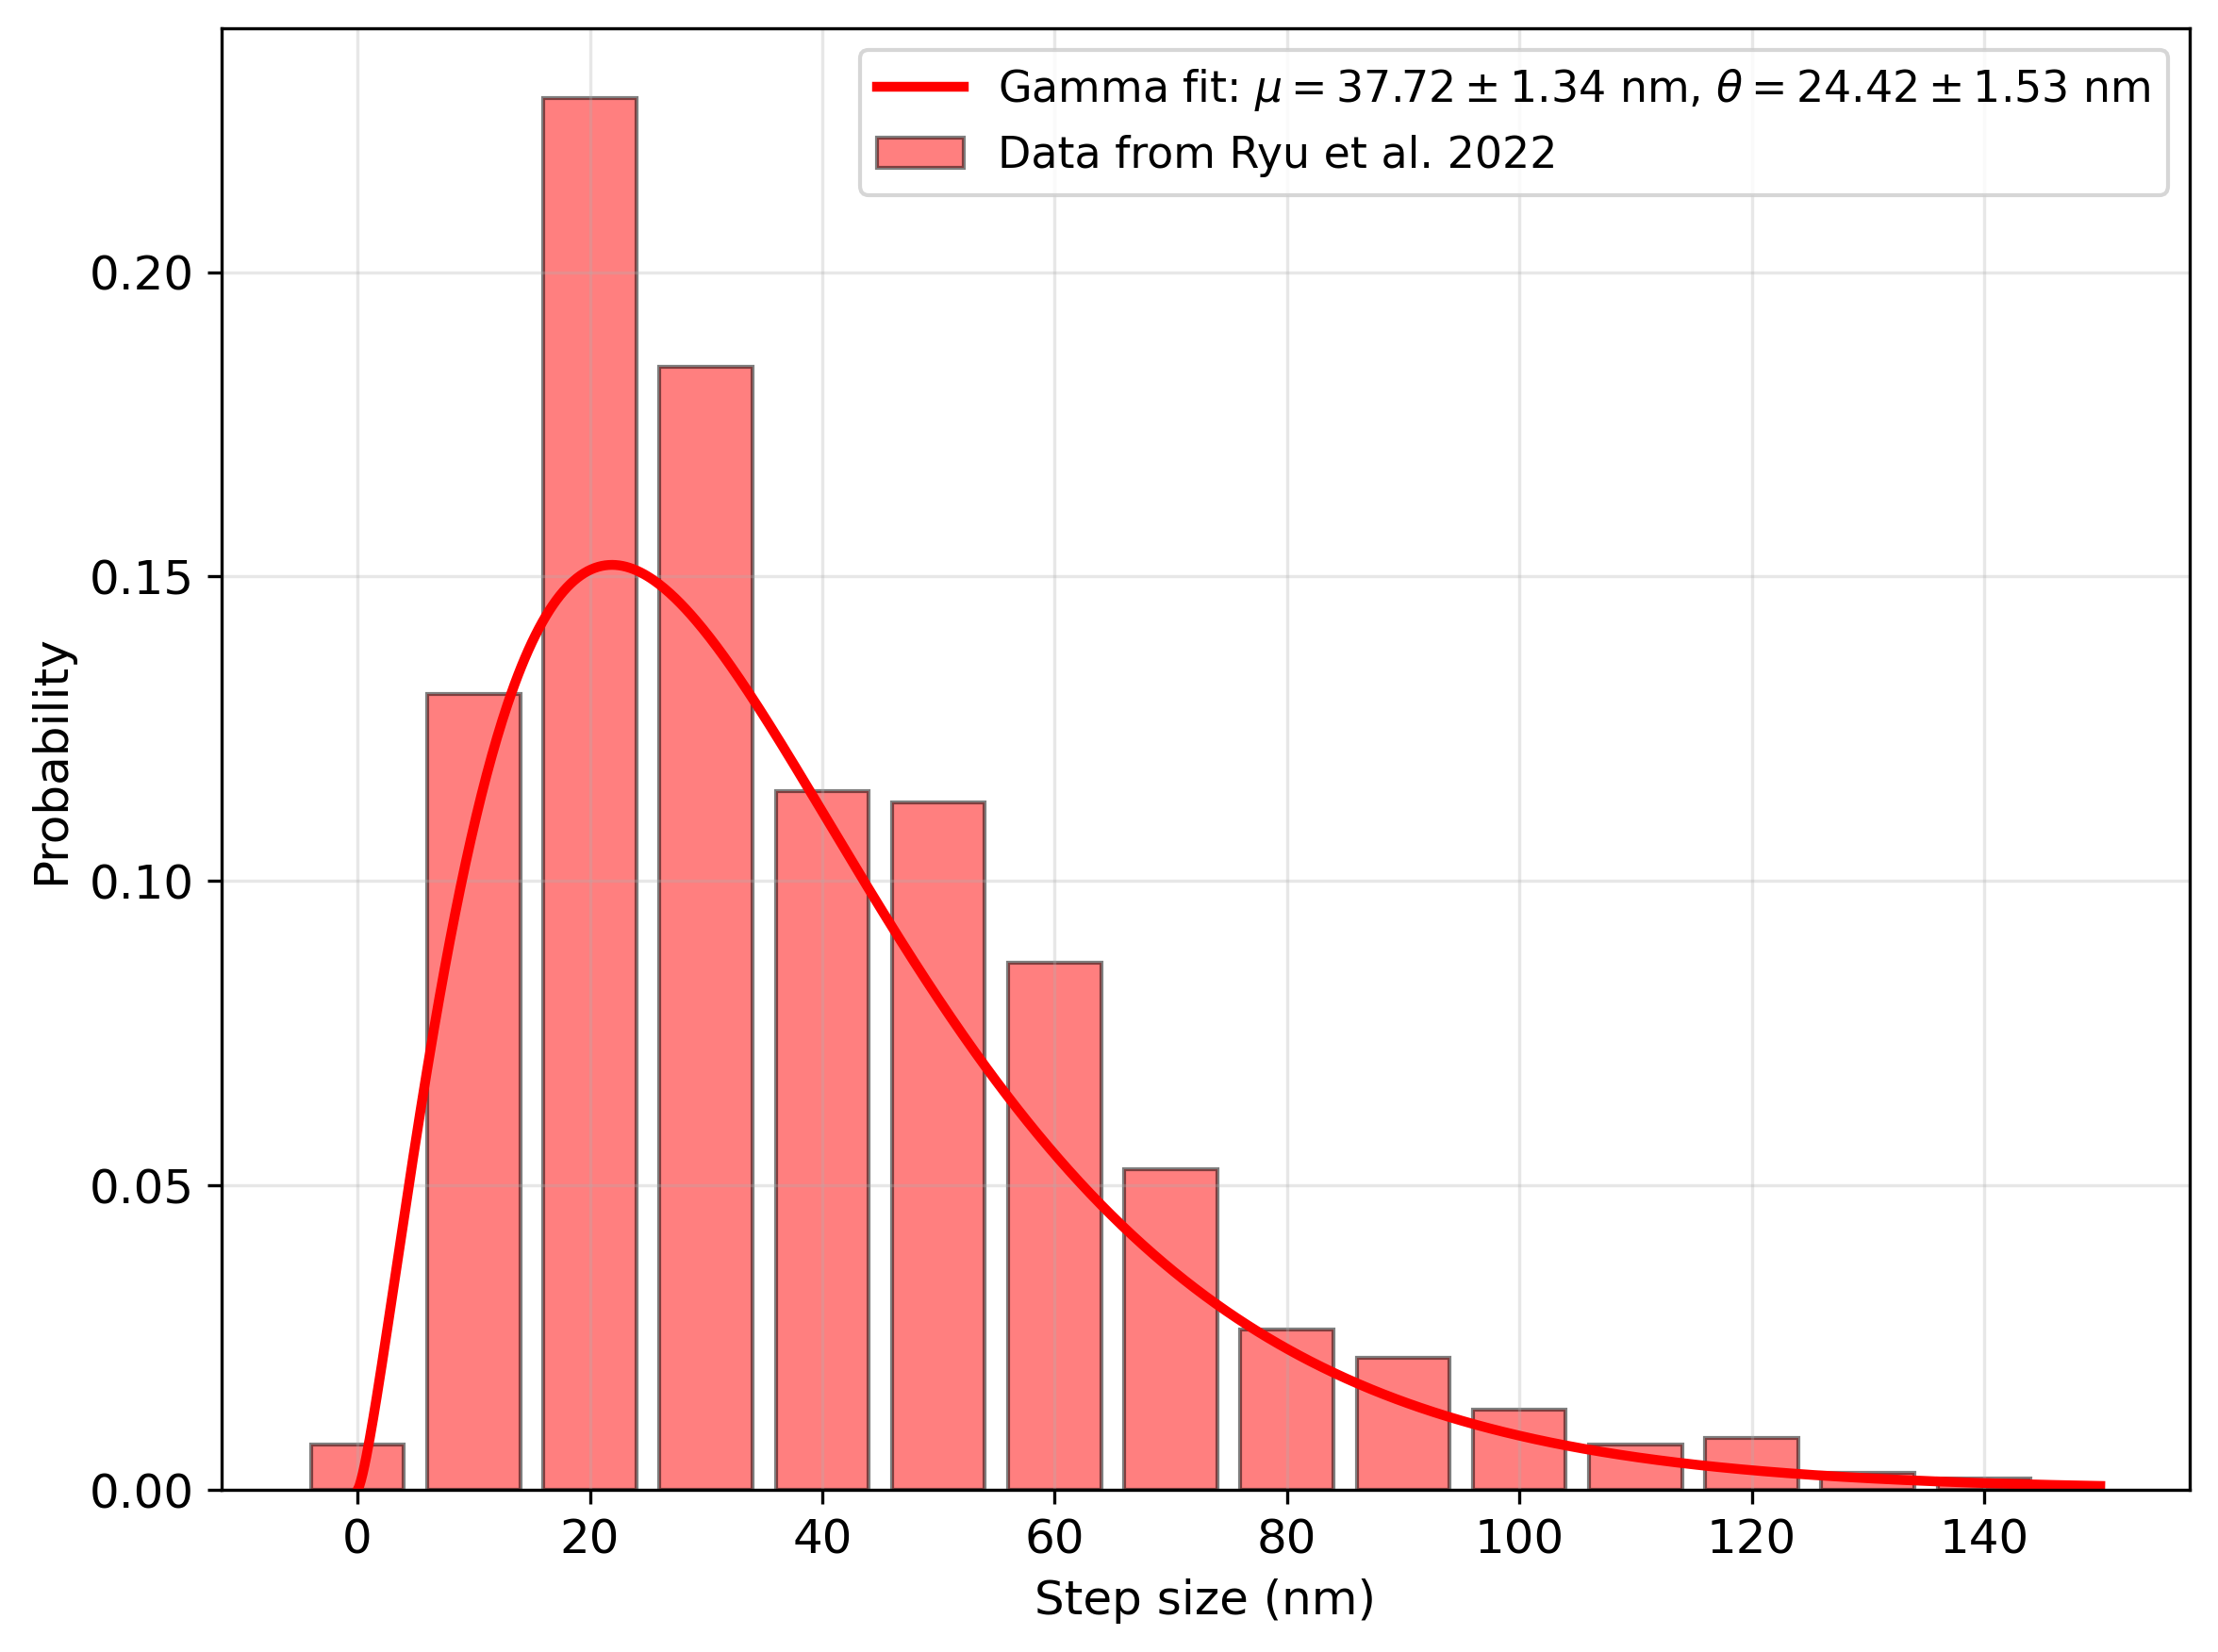

In [27]:
# Librairies
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from nucleo.simulation.probabilities import proba_gamma

plt.rcParams["font.size"] = 12


# ==========================================================
# Données expérimentales
# ==========================================================

step_array = np.arange(0, 150, 10)

frwd_counts = np.array(
    [8, 139, 243, 196, 122, 120, 92, 56, 28, 23, 14, 8, 9, 3, 2],
    dtype=float,
)

# Normalisation
frwd_array = frwd_counts / frwd_counts.sum()


# ==========================================================
# Gamma fit
# ==========================================================

def gamma_fit(L, mu, theta):
    """Gamma distribution using the model parametrization."""
    return proba_gamma(mu=mu, theta=theta, L=L)


# Fit directly to the experimental probabilities
popt, pcov = curve_fit(
    gamma_fit,
    step_array,
    frwd_array,
    p0=(40, 25),
    bounds=([1e-6, 1e-6], [np.inf, np.inf]),
)

mu_fit, theta_fit = popt

# Parameter uncertainties
mu_err, theta_err = np.sqrt(np.diag(pcov))


print(f"mu    = {mu_fit:.2f} ± {mu_err:.2f} nm")
print(f"theta = {theta_fit:.2f} ± {theta_err:.2f} nm")


# ==========================================================
# Fitted distribution
# ==========================================================

x_fine = np.linspace(0, 150, 1000)

p_fit = gamma_fit(
    x_fine,
    mu_fit,
    theta_fit,
)


# ==========================================================
# Plot
# ==========================================================

bin_width = 10 

plt.figure(figsize=(8, 6), dpi=300)

plt.bar(
    step_array,
    frwd_array,
    width=bin_width - 2,
    edgecolor="black",
    color="red",
    alpha=0.5,
    linewidth=1,
    label="Data from Ryu et al. 2022",
)

plt.plot(
    x_fine,
    p_fit * bin_width*5,
    linewidth=2.5,
    c="red",
    label=(
        rf"Gamma fit: "
        rf"$\mu={mu_fit:.2f}\pm{mu_err:.2f}$ nm, "
        rf"$\theta={theta_fit:.2f}\pm{theta_err:.2f}$ nm"
    ),
)

plt.xlabel("Step size (nm)")
plt.ylabel("Probability")
plt.grid(alpha=0.3)
plt.legend(fontsize=11)

plt.tight_layout()
plt.show()

In [28]:
conv = np.mean([0.246, 0.255, 0.257])
theta_bp = theta_fit / conv
mu_bp = mu_fit / conv
print(f"mu = {mu_bp:.2f} bp ; theta = {theta_bp:.2f} bp")

mu = 149.28 bp ; theta = 96.66 bp


λ = 0.385

---------------- Forward fit ----------------
μ = 37.72 ± 1.34 nm
θ = 24.42 ± 1.53 nm

---------------- Reverse fit ----------------
μ = 36.78 ± 0.74 nm
θ = 24.64 ± 0.88 nm


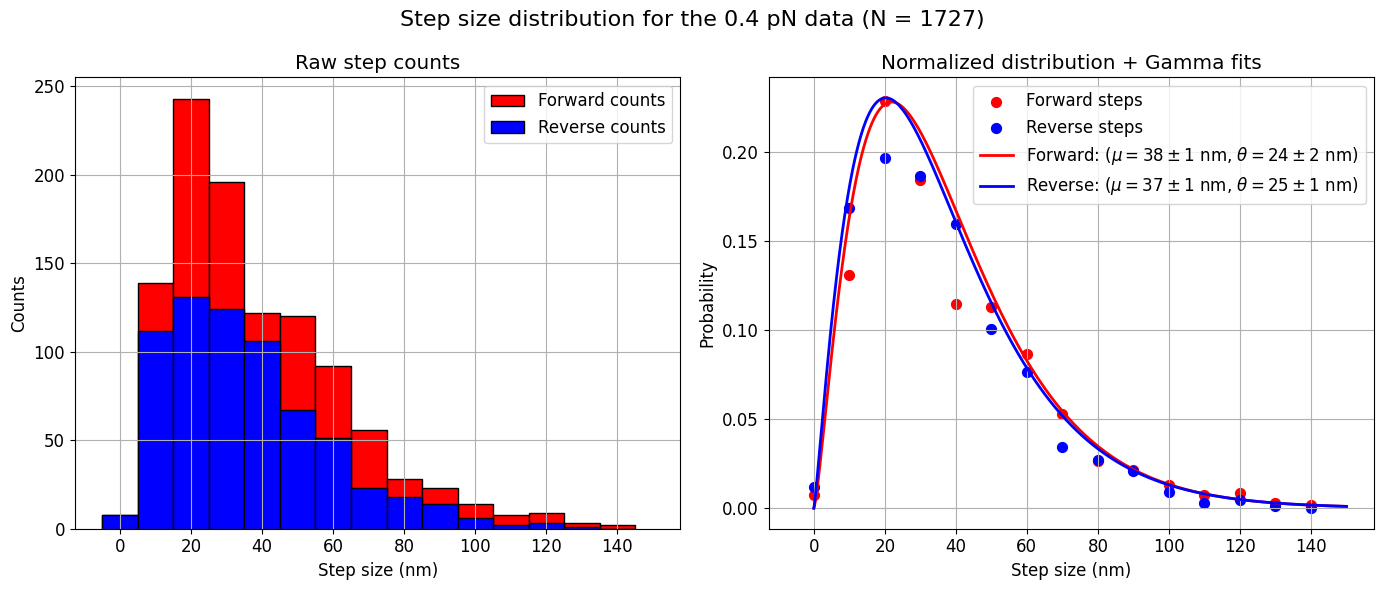


---------------- Forward fit ----------------
μ = 37.72 nm
θ = 24.42 nm
μ = 149.28 bp
θ = 96.66 bp

---------------- Reverse fit ----------------
μ = 36.78 nm
θ = 24.64 nm
μ = 145.55 bp
θ = 97.51 bp
μ = 0.97 sites
θ = 0.65 sites


In [36]:
# ─────────────────────────────────────────────
# 2 : Datas + Fits + Conversions
# ─────────────────────────────────────────────

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from nucleo.simulation.probabilities import proba_gamma

plt.rcParams["font.size"] = 12


# ==========================================================
# Données expérimentales
# ==========================================================

step_array = np.arange(0, 150, 10)

frwd_counts = np.array(
    [8, 139, 243, 196, 122, 120, 92, 56, 28, 23, 14, 8, 9, 3, 2],
    dtype=float,
)

rvrs_counts = np.array(
    [8, 112, 131, 124, 106, 67, 51, 23, 18, 14, 6, 2, 3, 1, 0],
    dtype=float,
)

lmbda = np.sum(rvrs_counts) / (
    np.sum(frwd_counts) + np.sum(rvrs_counts)
)

print(f"λ = {lmbda:.3f}")


# ==========================================================
# Distributions normalisées
# ==========================================================

frwd_array = frwd_counts / frwd_counts.sum()
rvrs_array = rvrs_counts / rvrs_counts.sum()


# ==========================================================
# Gamma fit
# ==========================================================

def gamma_fit(L, mu, theta):
    """Gamma distribution using the model parametrization."""
    return proba_gamma(mu=mu, theta=theta, L=L)


# ----------------------------------------------------------
# Forward fit
# ----------------------------------------------------------

popt_frwd, pcov_frwd = curve_fit(
    gamma_fit,
    step_array,
    frwd_array,
    p0=(40, 25),
    bounds=([1e-6, 1e-6], [np.inf, np.inf]),
)

mu_frwd, theta_frwd = popt_frwd
mu_frwd_err, theta_frwd_err = np.sqrt(np.diag(pcov_frwd))


# ----------------------------------------------------------
# Reverse fit
# ----------------------------------------------------------

popt_rvrs, pcov_rvrs = curve_fit(
    gamma_fit,
    step_array,
    rvrs_array,
    p0=(40, 25),
    bounds=([1e-6, 1e-6], [np.inf, np.inf]),
)

mu_rvrs, theta_rvrs = popt_rvrs
mu_rvrs_err, theta_rvrs_err = np.sqrt(np.diag(pcov_rvrs))


# ==========================================================
# Fit parameters
# ==========================================================

print("\n---------------- Forward fit ----------------")

print(f"μ = {mu_frwd:.2f} ± {mu_frwd_err:.2f} nm")
print(f"θ = {theta_frwd:.2f} ± {theta_frwd_err:.2f} nm")


print("\n---------------- Reverse fit ----------------")

print(f"μ = {mu_rvrs:.2f} ± {mu_rvrs_err:.2f} nm")
print(f"θ = {theta_rvrs:.2f} ± {theta_rvrs_err:.2f} nm")


# ==========================================================
# Fitted distributions
# ==========================================================

x_fit = np.linspace(0, 150, 1000)

y_fit_frwd = gamma_fit(
    x_fit,
    mu_frwd,
    theta_frwd,
)

y_fit_rvrs = gamma_fit(
    x_fit,
    mu_rvrs,
    theta_rvrs,
)


# ==========================================================
# Plot
# ==========================================================

bin_width = 10

fig, (ax_counts, ax_fit) = plt.subplots(
    1,
    2,
    figsize=(14, 6),
    sharex=True,
)


# ----------------------------------------------------------
# Raw counts
# ----------------------------------------------------------

ax_counts.bar(
    step_array,
    frwd_counts,
    width=bin_width,
    color="red",
    edgecolor="black",
    linewidth=1,
    label="Forward counts",
)

ax_counts.bar(
    step_array,
    rvrs_counts,
    width=bin_width,
    color="blue",
    edgecolor="black",
    linewidth=1,
    label="Reverse counts",
)

ax_counts.set_xlabel("Step size (nm)")
ax_counts.set_ylabel("Counts")
ax_counts.set_title("Raw step counts")
ax_counts.grid(True)
ax_counts.legend()


# ----------------------------------------------------------
# Normalized distributions + Gamma fits
# ----------------------------------------------------------

ax_fit.scatter(
    step_array,
    frwd_array,
    c="r",
    s=50,
    label="Forward steps",
)

ax_fit.scatter(
    step_array,
    rvrs_array,
    c="b",
    s=50,
    label="Reverse steps",
)

ax_fit.plot(
    x_fit,
    y_fit_frwd * len(step_array) * bin_width / 2,
    c="red",
    lw=2,
    label=(
        rf"Forward: "
        rf"$(\mu={mu_frwd:.0f}\pm{mu_frwd_err:.0f}$ nm, "
        rf"$\theta={theta_frwd:.0f}\pm{theta_frwd_err:.0f}$ nm)"
    ),
)

ax_fit.plot(
    x_fit,
    y_fit_rvrs * len(step_array) * bin_width / 2,
    c="blue",
    lw=2,
    label=(
        rf"Reverse: "
        rf"$(\mu={mu_rvrs:.0f}\pm{mu_rvrs_err:.0f}$ nm, "
        rf"$\theta={theta_rvrs:.0f}\pm{theta_rvrs_err:.0f}$ nm)"
    ),
)

ax_fit.set_xlabel("Step size (nm)")
ax_fit.set_ylabel("Probability")
ax_fit.set_title("Normalized distribution + Gamma fits")
ax_fit.grid(True)
ax_fit.legend()


# ----------------------------------------------------------
# Figure
# ----------------------------------------------------------

fig.suptitle(
    "Step size distribution for the 0.4 pN data (N = 1727)",
    fontsize=16,
)

plt.tight_layout()
plt.show()


# ==========================================================
# Conversions
# ==========================================================

# 1 bp = 0.2527 nm (average rise)
NM_PER_BP = np.mean([0.246, 0.255, 0.257])

# Number of bp represented by one simulation site
BP_PER_SITE = 150


# ----------------------------------------------------------
# Forward conversion
# ----------------------------------------------------------

print("\n---------------- Forward fit ----------------")

mu_bp_frwd = mu_frwd / NM_PER_BP
theta_bp_frwd = theta_frwd / NM_PER_BP

print(f"μ = {mu_frwd:.2f} nm")
print(f"θ = {theta_frwd:.2f} nm")

print(f"μ = {mu_bp_frwd:.2f} bp")
print(f"θ = {theta_bp_frwd:.2f} bp")


# ----------------------------------------------------------
# Reverse conversion
# ----------------------------------------------------------

print("\n---------------- Reverse fit ----------------")

mu_bp_rvrs = mu_rvrs / NM_PER_BP
theta_bp_rvrs = theta_rvrs / NM_PER_BP

mu_site_rvrs = mu_bp_rvrs / BP_PER_SITE
theta_site_rvrs = theta_bp_rvrs / BP_PER_SITE

print(f"μ = {mu_rvrs:.2f} nm")
print(f"θ = {theta_rvrs:.2f} nm")

print(f"μ = {mu_bp_rvrs:.2f} bp")
print(f"θ = {theta_bp_rvrs:.2f} bp")

print(f"μ = {mu_site_rvrs:.2f} sites")
print(f"θ = {theta_site_rvrs:.2f} sites")

# .